<a href="https://colab.research.google.com/github/plnu-biomechanics/kin4042/blob/main/notebooks/kin4042_lab1_key.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.pointloma.edu/sites/default/files/styles/basic_page/public/images/PLNU_Biomechanics_Lab_green_yellowSD_HiRes.png" width=400>

## **KIN 4042 Sports Informatics**
Instructor: Arnel Aguinaldo, PhD

**Lab 1: Predicting Bat Speed**

In this lab, you will ingest, parse, and quality check data metrics that were previously collected from baseball players with CMJ and IMTP performance testing. Two datasets will be used for this lab:

*   `plnu_hp_batspeed.csv` from the PLNU Biomechanics Lab
*   `hp_obp.csv` from Driveline's Open Biomechanics Project


To further process the data for this lab, follow the steps in this **Colab notebook**, which contains instructions and sample code on how to wrangle and analyze the data.

> **Instructor Key:** GenAI prompt cells are completed in this version.


### Create your own Colab Notebook

1. Go to **File -> New notebook in Drive** to open a new notebook in your Python environment:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/file_notebook.png" width=450>

2. Rename your Colab notebook using this naming format: **lastname_kin4042_lab#.ipynb** (e.g., "aguinaldo_kin4042_lab1.ipynb")
3. Click on the **+ Code** option above to insert a new code cell: <br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/addcode.png" width=280>

4. The data you will parse and analyze for this lab will be temporarily stored in your Colab's runtime directory, which can be accessed by clicking on the folder icon in the left menu:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/colab_folder.png" width=400>

5. Copy the following lines of code to import the packages needed for this analysis and to load the data files into your working directory. **Note**: These files are "runtime" access only, meaning they are only temporarily stored in your working directory and show up when your notebook is in session.


## 🔄 Data Ingestion - Method 1

This is a simple method of ingesting data into your working directory that involves minimal coding. First let's create a lab folder in your working directory using just these 3 lines of code:


In [ ]:
# CREATE LAB FOLDER IN YOUR WORKING DIRECTORY

# import the os library to your working environment, allowing access to the
# libraries and functions required to read and write to your working environment
import os

# create a data_dir variable with a string value of your directory
data_dir = "kin4042/lab1"
os.makedirs(data_dir, exist_ok=True)

print("Created lab directory.")


Created lab directory.


Your working directory should now look something like this:

<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin4042/main/notebooks/images/kin4042_create-lab-directory.png" width=400>

Next, download the following file and upload it to your working directory:

*   [plnu_hp_batspeed.csv](https://drive.google.com/file/d/1Lao2atJbcHGfK2_z9o42gtDM4YzjZSC8/view?usp=sharing)

Hover your mouse over the 3 vertical dots on the right side of the `lab1` folder to show the expanded menu:

<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin4042/main/notebooks/images/kin4042_directory_menu.png" width=400>

Then upload the file:

<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin4042/main/notebooks/images/kin4042_upload_file.png" width=400>


## 🔄 Data Ingestion - Method 2

Now let's now pull data from the OpenBiomechanics Project (OBP) on GitHub, which is an initiative started by Driveline Baseball Research & Development to provide raw (in the form of cleaned C3D files) and processed (full signal + point of interest) sports biomechanics data to the general public.

In [ ]:
# Import the URL library to access publicly available data on the web
import urllib.request

# This is the raw URL for the high performance data file (*.csv) on GitHub
url = (
    "https://raw.githubusercontent.com/drivelineresearch/"
    "openbiomechanics/refs/heads/main/high_performance/data/hp_obp.csv"
)

# Define data_path of the file on your working directory
data_filename = "hp_obp.csv"
data_path = os.path.join(data_dir, data_filename)

# --------------------------------------------------
# Download file directly from GitHub
# --------------------------------------------------
urllib.request.urlretrieve(url, data_path)

print("Existing files in the lab directory:")
print(os.listdir(data_dir))

Existing files in the lab directory:
['hp_obp.csv', 'plnu_hp_batspeed.csv']


## 🔄 Data Frames

<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin4042/main/notebooks/images/pandas_logo.jpg" width=400>

Before the data can be analyzed, they need to be parsed into what are called `DataFrames`, which are two-dimensional tabular data structure with labeled columns and rows. Think of them like spreadsheets with an organized structure that can be manipulated and analyzed in Python.

In this lab, we will use the powerful `pandas` library to create two data frames from the `hp_obp.csv` and `plnu_hp_batspeed.csv` files.

You can use your favorite GenAI agent to help you with populating these two data frames.

### ✋ GenAI prompt:
Generate code that will load data frames with data from the two `*.csv` files as well as inspect and print out the column name for each variable for analysis. Count the number of unique players and swings per player included in the data frames made for `plnu_hp_batspeed.csv` and `hp_obp.csv`, excluding players who do not have bat speed data. Be sure to state in a comment the GenAI agent you used to generate the code similar to this comment:

```
# =======================================
#  Code generated or assisted by Claude
# =======================================
```



In [ ]:
# ============================================
# Code generated or assisted by ChatGPT (GPT-5.6 Sol)
# ============================================

import pandas as pd
import os

# Load the two CSV files into pandas DataFrames
plnu_df = pd.read_csv(os.path.join(data_dir, "plnu_hp_batspeed.csv"))
obp_df = pd.read_csv(os.path.join(data_dir, "hp_obp.csv"))

# ------------------------------------------------------------
# Inspect the variables available in each DataFrame
# ------------------------------------------------------------
print("PLNU dataframe shape:", plnu_df.shape)
print("\nPLNU variables:")
for col in plnu_df.columns:
    print(f"  {col}")

print("\n" + "=" * 70)
print("OBP dataframe shape:", obp_df.shape)
print("\nOBP variables:")
for col in obp_df.columns:
    print(f"  {col}")

# ------------------------------------------------------------
# Keep only rows that contain bat-speed data
# ------------------------------------------------------------
plnu_batspeed = plnu_df.dropna(subset=["Mean_Bat_Speed_mph"]).copy()
obp_batspeed = obp_df.dropna(subset=["bat_speed_mph"]).copy()

# ------------------------------------------------------------
# Count unique players
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("BAT-SPEED SAMPLE SIZES")
print("=" * 70)
print(f"PLNU unique players: {plnu_batspeed['Participant_ID'].nunique()}")
print(f"OBP unique players:  {obp_batspeed['athlete_uid'].nunique()}")

# ------------------------------------------------------------
# Count bat-speed observations per player
# ------------------------------------------------------------
plnu_counts = (
    plnu_batspeed.groupby("Participant_ID")
    .size()
    .reset_index(name="n_bat_speed_observations")
)

obp_counts = (
    obp_batspeed.groupby("athlete_uid")
    .size()
    .reset_index(name="n_bat_speed_observations")
)

print("\nPLNU observations per player:")
print(plnu_counts.to_string(index=False))

print("\nOBP observations per player:")
print(obp_counts.sort_values("n_bat_speed_observations", ascending=False).to_string(index=False))

print("\nObservation range per player:")
print(
    f"PLNU: {plnu_counts['n_bat_speed_observations'].min()}-"
    f"{plnu_counts['n_bat_speed_observations'].max()}"
)
print(
    f"OBP:  {obp_counts['n_bat_speed_observations'].min()}-"
    f"{obp_counts['n_bat_speed_observations'].max()}"
)

# NOTE: Neither file contains an explicit swing/trial ID. Therefore, the
# counts above are bat-speed observations (rows), not confirmed individual swings.


PLNU dataframe shape: (16, 16)

PLNU variables:
  Participant_ID
  Dom_Grip_Strength_kg
  L_Hip_IR_degrees
  R_Hip_IR_degrees
  L_Hip_ER_degrees
  R_Hip_ER_degrees
  L_Hip_Abduction_N
  R_Hip_Abduction_N
  L_Hip_Adduction_N
  R_Hip_Adduction_N
  CMJ_height_cm
  Squat_Jump_height_cm
  IMTP_force_N
  L_NordBord_ISO30_N
  R_NordBord_ISO30_N
  Mean_Bat_Speed_mph

OBP dataframe shape: (1934, 53)

OBP variables:
  test_date
  playing_level
  bat_speed_mph_group
  pitch_speed_mph_group
  jump_height_(imp-mom)_[cm]_mean_cmj
  lower-limb_stiffness_[n/m]_mean_cmj
  peak_power_[w]_mean_cmj
  peak_power_/_bm_[w/kg]_mean_cmj
  eccentric_braking_rfd_[n/s]_mean_cmj
  eccentric_duration_[ms]_mean_cmj
  concentric_duration_[ms]_mean_cmj
  rsi-modified_[m/s]_mean_cmj
  countermovement_depth_[cm]_mean_cmj
  cmj_stiffness_asymmetry_[%_l,r]_mean_cmj
  eccentric_deceleration_impulse_(asymmetry)_[%_l,r]_mean_cmj
  p1_concentric_impulse_asymmetry_[%_l,r]_mean_cmj
  p2_concentric_impulse_asymmetry_[%_l,r]_mean

## 📓Lab Note

Take note of the number of players with bat speed data in each data frame and the number of swings per player (range is fine).

## 📈 Inspection

In this lab, the dependent variable of interest is **bat speed** (`Mean_Bat_Speed_mph` from `plnu_df`, `bat_speed_mph` from `obp_df`), which is used to operationally define batting performance. We are also interested in how **grip strength** and **IMTP peak force** influence **bat speed**.

First, we need to inspect the quality of the variables of interest by checking for missing values and outliers.


## 🧹 Data Quality Check: Missing Values

It's important to check for missing values in a dataset as they can impact analysis and modeling. We'll count the number of `NaN` values for each column in `plnu_df` and `obp_df`.

###✋ GenAI prompt ###
Generate code that will count the number of `NaN` values in both data frames, `plnu_df` and `obp_df`.

In [ ]:
# ============================================
# Code generated or assisted by ChatGPT (GPT-5.6 Sol)
# ============================================

# Count NaN values in every column of each DataFrame
print("NaN values in plnu_df:")
print(plnu_df.isna().sum())

print("\nNaN values in obp_df:")
print(obp_df.isna().sum())

# Optional: total number of NaN cells in each DataFrame
print("\nTotal NaN values in plnu_df:", plnu_df.isna().sum().sum())
print("Total NaN values in obp_df:", obp_df.isna().sum().sum())


NaN values in plnu_df:
Participant_ID          0
Dom_Grip_Strength_kg    0
L_Hip_IR_degrees        0
R_Hip_IR_degrees        0
L_Hip_ER_degrees        0
R_Hip_ER_degrees        0
L_Hip_Abduction_N       0
R_Hip_Abduction_N       0
L_Hip_Adduction_N       0
R_Hip_Adduction_N       0
CMJ_height_cm           0
Squat_Jump_height_cm    0
IMTP_force_N            0
L_NordBord_ISO30_N      0
R_NordBord_ISO30_N      0
Mean_Bat_Speed_mph      0
dtype: int64

NaN values in obp_df:
test_date                                                         0
playing_level                                                     0
bat_speed_mph_group                                            1011
pitch_speed_mph_group                                           836
jump_height_(imp-mom)_[cm]_mean_cmj                              21
lower-limb_stiffness_[n/m]_mean_cmj                              21
peak_power_[w]_mean_cmj                                          21
peak_power_/_bm_[w/kg]_mean_cmj                  

### Strategies for Handling Missing Values in `obp_df`

Given the output from the `isnull().sum()` for `obp_df`, we can see several columns with a considerable number of missing values. The approach to handling these depends on the nature of the data, the extent of missingness, and the goals of your analysis. There are several strategies that are commonly used in handling missingness, including deleting rows or columns, imputing missing values with the mean or median, or interpolating between points. For now, however, we will do nothing and deal with specific variables of interest in this data frame as needed.

## 📈 Outlier Detection: IQR Method

We will use the Interquartile Range (IQR) method to identify outliers in the `Mean_Bat_Speed_mph` column. The IQR is the range between the first quartile (Q1) and the third quartile (Q3). Outliers are typically defined as values that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.

### ✋ GenAI prompt ###
Generate code that will remove any outliers in `Mean_Bat_Speed_mph` as defined by values outside the IQR.

In [ ]:
# ============================================
# Code generated or assisted by ChatGPT (GPT-5.6 Sol)
# ============================================

# Remove outliers from PLNU mean bat speed using the 1.5 x IQR rule
metric = "Mean_Bat_Speed_mph"

q1 = plnu_df[metric].quantile(0.25)
q3 = plnu_df[metric].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Keep NaN values for now; remove only non-missing values outside the bounds
outlier_mask = (
    plnu_df[metric].notna()
    & ((plnu_df[metric] < lower_bound) | (plnu_df[metric] > upper_bound))
)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Bat-speed outliers removed: {outlier_mask.sum()}")

plnu_df_cleaned = plnu_df.loc[~outlier_mask].copy()

print(f"Rows before cleaning: {len(plnu_df)}")
print(f"Rows after bat-speed cleaning: {len(plnu_df_cleaned)}")


Q1: 67.22
Q3: 71.88
IQR: 4.65
Lower bound: 60.25
Upper bound: 78.85
Bat-speed outliers removed: 0
Rows before cleaning: 16
Rows after bat-speed cleaning: 16


###✋ GenAI prompt ###
Generate code that will also remove any outliers in the following variables using the IQR method:

*   `Dom_Grip_Strength_kg` from `plnu_hp_df`
*   `bat_speed_mph` and `peak_vertical_force_[n]_max_imtp` from `obp_df`

Include the final sample sizes by player and by swing, if available.


In [ ]:
# ============================================
# Code generated or assisted by ChatGPT (GPT-5.6 Sol)
# ============================================

# Helper function: remove outliers in one variable using the 1.5 x IQR rule
def remove_iqr_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        df[column].notna()
        & ((df[column] < lower_bound) | (df[column] > upper_bound))
    )

    print(f"\n{column}")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Outliers removed: {outlier_mask.sum()}")

    return df.loc[~outlier_mask].copy()

# ------------------------------------------------------------
# PLNU: continue from the bat-speed-cleaned DataFrame created above
# ------------------------------------------------------------
plnu_df_cleaned = remove_iqr_outliers(
    plnu_df_cleaned,
    "Dom_Grip_Strength_kg"
)

# ------------------------------------------------------------
# OBP: remove outliers from bat speed and IMTP peak force
# ------------------------------------------------------------
obp_df_cleaned = obp_df.copy()

for column in ["bat_speed_mph", "peak_vertical_force_[n]_max_imtp"]:
    obp_df_cleaned = remove_iqr_outliers(obp_df_cleaned, column)

# ------------------------------------------------------------
# Final complete-case samples for the analyses used in this lab
# ------------------------------------------------------------
plnu_analysis = plnu_df_cleaned.dropna(
    subset=["Mean_Bat_Speed_mph", "Dom_Grip_Strength_kg"]
).copy()

obp_analysis = obp_df_cleaned.dropna(
    subset=["bat_speed_mph", "peak_vertical_force_[n]_max_imtp"]
).copy()

# ------------------------------------------------------------
# Final sample sizes
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL COMPLETE-CASE SAMPLE SIZES")
print("=" * 70)

print(
    f"PLNU: {plnu_analysis['Participant_ID'].nunique()} players, "
    f"{len(plnu_analysis)} observations"
)
print(
    f"OBP:  {obp_analysis['athlete_uid'].nunique()} players, "
    f"{len(obp_analysis)} observations"
)

# Count observations per player after sanitization
plnu_final_counts = plnu_analysis.groupby("Participant_ID").size()
obp_final_counts = obp_analysis.groupby("athlete_uid").size()

print(
    f"PLNU observations per player: "
    f"{plnu_final_counts.min()}-{plnu_final_counts.max()}"
)
print(
    f"OBP observations per player: "
    f"{obp_final_counts.min()}-{obp_final_counts.max()}"
)

# NOTE: No explicit swing/trial identifier is present in either file, so
# these are counts of observations rather than confirmed individual swings.



Dom_Grip_Strength_kg
  Lower bound: 476.62
  Upper bound: 707.62
  Outliers removed: 2

bat_speed_mph
  Lower bound: 46.07
  Upper bound: 84.68
  Outliers removed: 25

peak_vertical_force_[n]_max_imtp
  Lower bound: 1740.00
  Upper bound: 5872.80
  Outliers removed: 12

FINAL COMPLETE-CASE SAMPLE SIZES
PLNU: 14 players, 14 observations
OBP:  436 players, 742 observations
PLNU observations per player: 1-1
OBP observations per player: 1-9


## 📓Lab Note

Take note of the final number of players with bat speed data in each data frame and the number of swings per player after data sanitization.

## 📊 Data Visualization: Bat Speed Summary Statistics

Let's visualize the **bat speed** descriptive statistics by `playing_level` from `obp_df_cleaned` using box plots. This can help us see how bat speed differs across playing levels.

###✋ GenAI prompt ###
Generate box plots for `bat_speed_mph` in `obp_df_cleaned` stratified by `playing_level` with the order explicity set from `High School` through `Pro`.

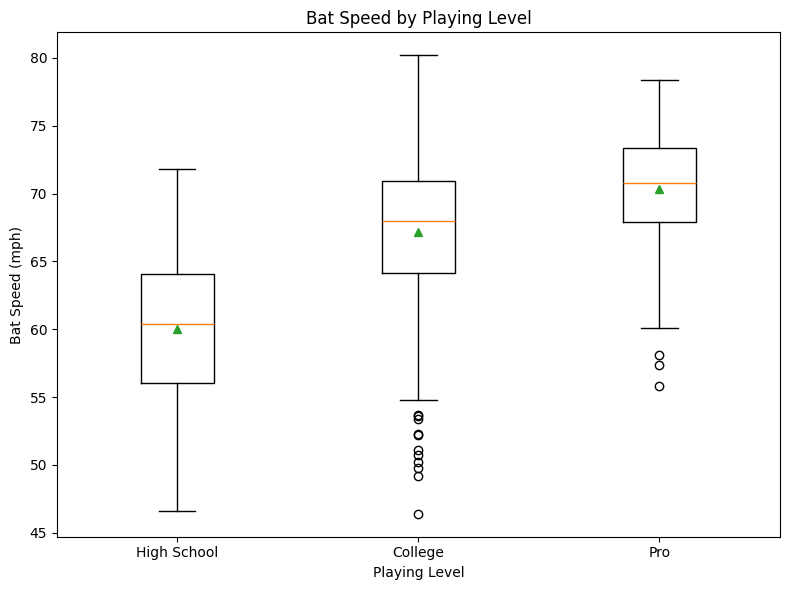

               players  observations
playing_level                       
High School        207           299
College            266           466
Pro                 66           126


In [ ]:
# ============================================
# Code generated or assisted by ChatGPT (GPT-5.6 Sol)
# ============================================

import matplotlib.pyplot as plt

metric = "bat_speed_mph"
level_order = ["High School", "College", "Pro"]

plot_df = obp_df_cleaned.dropna(subset=["playing_level", metric]).copy()

# Create one list of bat-speed values for each playing level
box_data = [
    plot_df.loc[plot_df["playing_level"] == level, metric].values
    for level in level_order
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(box_data, tick_labels=level_order, showmeans=True)

ax.set_title("Bat Speed by Playing Level")
ax.set_xlabel("Playing Level")
ax.set_ylabel("Bat Speed (mph)")

plt.tight_layout()
plt.show()

# Print sample sizes contributing to the plot
sample_sizes = (
    plot_df.groupby("playing_level")
    .agg(
        players=("athlete_uid", "nunique"),
        observations=(metric, "count")
    )
    .reindex(level_order)
)

print(sample_sizes)


## 📓Lab Note

Copy the box plot and paste it onto your lab write-up.

## 📊 Data Visualization: Bat Speed vs. Grip Strength

Let's visualize the relationship between **bat speed** and **grip strength** from `plnu_df_cleaned` using a scatter plot. This can help us understand if there's any correlation between these two variables.

###✋ GenAI prompt ###
Generate code that creates a scatter plot of bat speed and grip strength on the y and x axes, respectively. Add the coefficient of determination value and the regression line on the plot to indicate the strength of the high performance testing metric in predicting bat speed.

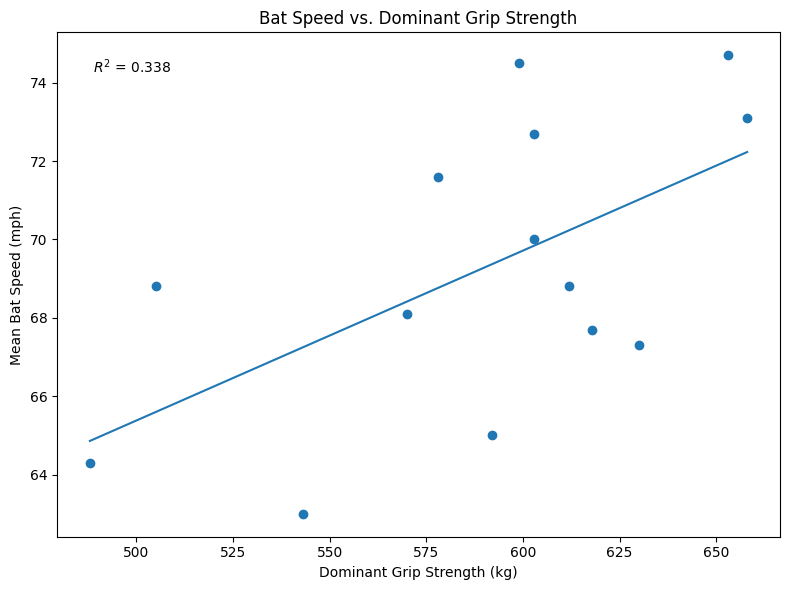

R^2 = 0.338
n = 14 players


In [ ]:
# ============================================
# Code generated or assisted by ChatGPT (GPT-5.6 Sol)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

x_var = "Dom_Grip_Strength_kg"
y_var = "Mean_Bat_Speed_mph"

plot_df = plnu_df_cleaned.dropna(subset=[x_var, y_var]).copy()

x = plot_df[x_var].to_numpy()
y = plot_df[y_var].to_numpy()

# Simple linear regression: y = slope*x + intercept
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# Coefficient of determination (R^2)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Smooth x values for drawing the regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y)
ax.plot(x_line, y_line)

ax.set_title("Bat Speed vs. Dominant Grip Strength")
ax.set_xlabel("Dominant Grip Strength (kg)")
ax.set_ylabel("Mean Bat Speed (mph)")

ax.text(
    0.05, 0.95,
    f"$R^2$ = {r_squared:.3f}",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

print(f"R^2 = {r_squared:.3f}")
print(f"n = {len(plot_df)} players")


## 📓Lab Note

Copy the scatter plot and paste it onto your lab write-up.

## 📊 Data Visualization: Bat Speed vs. IMTP Peak Force

Let's visualize the relationship between **bat speed** and **IMTP peak force** from `obp_df` using a scatter plot. This can help us understand if there's any correlation between these two variables.

###✋ GenAI prompt ###
Generate code that creates a scatter plot of bat speed and IMTP Peak Force on the y and x axes, respectively. Add the coefficient of determination value and regression line on the plot to indicate the strength of the high performance testing metric on bat speed.

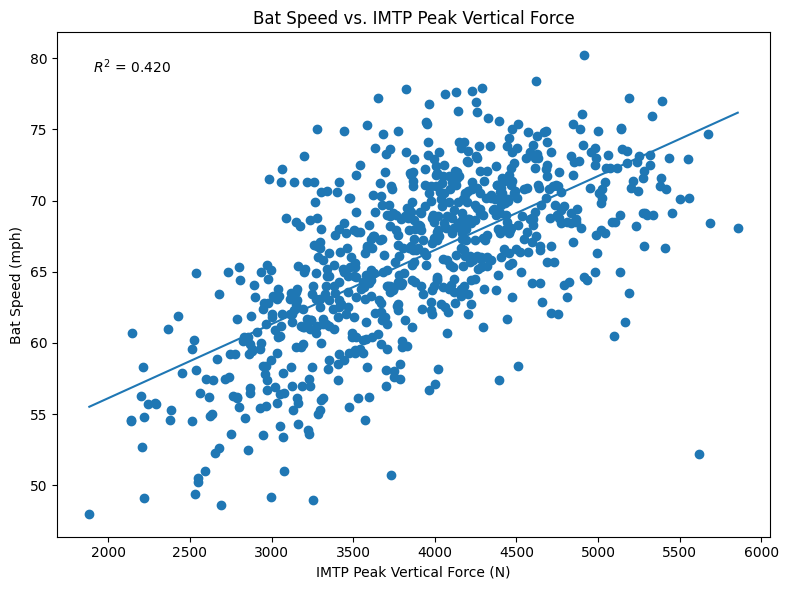

R^2 = 0.420
Players = 436
Observations = 742


In [ ]:
# ============================================
# Code generated or assisted by ChatGPT (GPT-5.6 Sol)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

x_var = "peak_vertical_force_[n]_max_imtp"
y_var = "bat_speed_mph"

plot_df = obp_df_cleaned.dropna(subset=[x_var, y_var]).copy()

x = plot_df[x_var].to_numpy()
y = plot_df[y_var].to_numpy()

# Simple linear regression: y = slope*x + intercept
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# Coefficient of determination (R^2)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Smooth x values for drawing the regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y)
ax.plot(x_line, y_line)

ax.set_title("Bat Speed vs. IMTP Peak Vertical Force")
ax.set_xlabel("IMTP Peak Vertical Force (N)")
ax.set_ylabel("Bat Speed (mph)")

ax.text(
    0.05, 0.95,
    f"$R^2$ = {r_squared:.3f}",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

print(f"R^2 = {r_squared:.3f}")
print(f"Players = {plot_df['athlete_uid'].nunique()}")
print(f"Observations = {len(plot_df)}")


## 📓Lab Note

Copy the scatter plot and paste it onto your lab write-up.

## 📔 Final Notes ##

☝ Notice in these last couple of prompts, the actual names of the bat speed, grip strength, and IMTP force metrics were not used. By now, the AI agent knows the exact names of the variables of interest so there's no need to list them exactly in your prompts (but it helps!). Based on the plots and R^2 values, it looks IMTP force is more predictive of bat speed than grip strength!

💡 **What other high performance testing metrics can predict bat speed?**

Let's put your vibe code skills to the test and complete the lab by selecting two more potential bat speed predictors from either data frame using the same approach we did for grip strength and IMTP force. Use the above prompts and/or code to generate the scatter plots of your selected independent variables.




In [ ]:
# **********************************
# ENTER YOUR AI-ASSISTED CODE BELOW
# **********************************